# Домашнее задание 2. Работа с изображениями

В этом задании предлагается решить простейшую задачу рапознавания лиц. Вам нужно будет научить модель для пары картинок определять, разные ли люди на них изображены.

Работать будем с датасетом фотографий известных людей. Скачать его можно [тут](https://disk.360.yandex.ru/d/oAmJgPESjP33hg). В нём представлены 150 человек, для каждого по 6-9 фотографий. Всего около 1000 изображений.

__Задание__. Вам потребуется выполнить два задания:

1) Реализовать модель бинарной классификации и добиться приемлемого качества.

2) Реализовать триплетную функцию потерь и улучшить качество предсказаний с ее помощью.

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

__Во всех заданиях будем придерживаться следующих правил__:
1. Использовать внешние данные для обучения строго запрещено. Также запрещено обучаться на валидационной выборке.
2. Все задания должны быть выполнены без использования предобученных моделей и готовых реализаций. Тем не менее:
    - В заданиях, где требуется достичь некоторого качества модели, разрешается использовать предобученные модели. Но __оценка за задние будет снижена__ (для каждого задания будет отдельно указано, на сколько).
    - В некоторых заданиях может сильно помочь библотека [pytorch-metric-learning](https://kevinmusgrave.github.io/pytorch-metric-learning/). Вы можете использовать готовые реализации из неё, но __максимальный балл за задание также будет снижен__.

__Советы и указания__:
 - Наверняка вам потребуется много гуглить о том, как заставить это всё работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Рекомендуем использовать шаблоны ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Правильно нормализуйте данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени. Можно написать свою модель руками, а можно импортировать не предобученную сетку известной архитектуры из модуля `torchvision.models`. Один из способов как можно сделать: [документация (полезная)](https://pytorch.org/vision/stable/models.html)
 - Используйте все возможные методы оптимизации и эксперемнтируйте с ними.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
    * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
    * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе.

Good luck & have fun! :)

In [1]:
import os
import tqdm
import numpy as np
import torch
import pandas as pd
import random
import torchvision
from sklearn.metrics import roc_auc_score, accuracy_score
import torch.utils.data as data
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.transforms.v2 as v2
import torch.nn as nn
from IPython.display import clear_output

In [2]:
# Можно использовать, но балл за соответствующие задания будет снижен.
import pytorch_metric_learning.distances
import pytorch_metric_learning.samplers
import pytorch_metric_learning.losses

In [3]:
# Обязательно вызывайте эту функцию перед каждый запуском обучения!
# Если проверяющий не сможет воспроизвести результат, оценка за задание будет снижена.
def set_random_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device('mps' if torch.mps.is_available() else 'cpu')

### [1.5 балла] Часть 1. Подготовка данных.

##### [0.5 балла] Задание 1.1. Считать датасет.

Сначала нужно считать датасет с фотографиями и посмотреть на его устройство.

In [4]:
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

train_ds = torchvision.datasets.ImageFolder("data/training", transform = transform)
test_ds = torchvision.datasets.ImageFolder("data/testing", transform = transform)

In [5]:
unique, counts = np.unique(train_ds.targets, return_counts=True)
max(counts)

np.int64(9)

In [26]:
from torchvision.utils import save_image
from collections import defaultdict

dataset = torchvision.datasets.ImageFolder("data/training", transform=transform)

class_images = defaultdict(list)
for i, (img, label) in enumerate(dataset):
    class_images[label].append((i, img))

augment = v2.Compose([
    v2.RandomAutocontrast(),
    v2.RandomHorizontalFlip(0.5),
    v2.RandomRotation(12),
    v2.ColorJitter(0.25, 0.25),
])

save_root = "data/train_augmented"
os.makedirs(save_root, exist_ok=True)

for label, items in tqdm.tqdm(class_images.items(), desc="Augmenting"):
    cls_name = dataset.classes[label]
    cls_save_path = os.path.join(save_root, cls_name)
    os.makedirs(cls_save_path, exist_ok=True)

    for idx, (i, img) in enumerate(items):
        save_image(img, os.path.join(cls_save_path, f"{idx:03d}_orig.png"))

    count = len(items)
    aug_index = count
    while count < 36:
        i, img = random.choice(items)
        aug_img = augment(img)
        save_image(aug_img, os.path.join(cls_save_path, f"{aug_index:03d}_aug.png"))
        count += 1
        aug_index += 1

Augmenting: 100%|██████████| 148/148 [00:38<00:00,  3.85it/s]


Давайте посмотрим на примеры фотографий. Нарисуйте несколько.

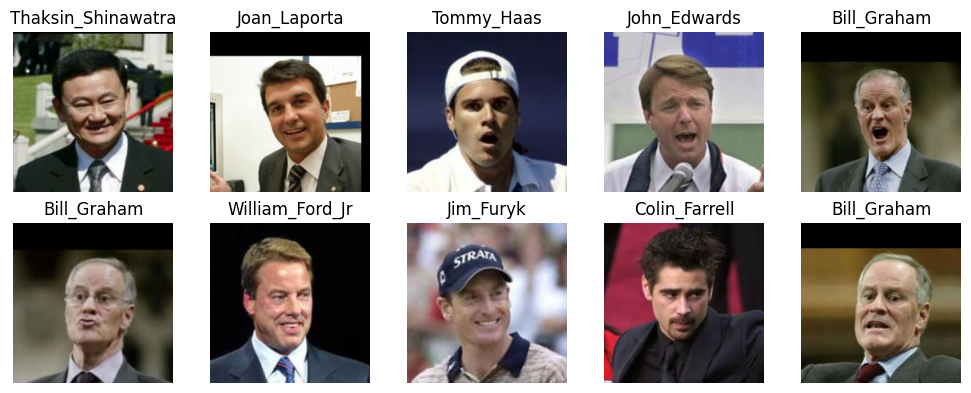

In [6]:
f, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax in axes.flatten():
    randnum = np.random.randint(0, len(train_ds))
    ax.imshow(np.transpose(train_ds[randnum][0], (1, 2, 0)))
    ax.set_title(train_ds.classes[train_ds[randnum][1]])
    ax.set_axis_off()
plt.tight_layout()
plt.show()

Наконец, следует вывести распределение фотографий по людям и убедиться, что для каждого человека действительно предствалено 6-9 фотографий.

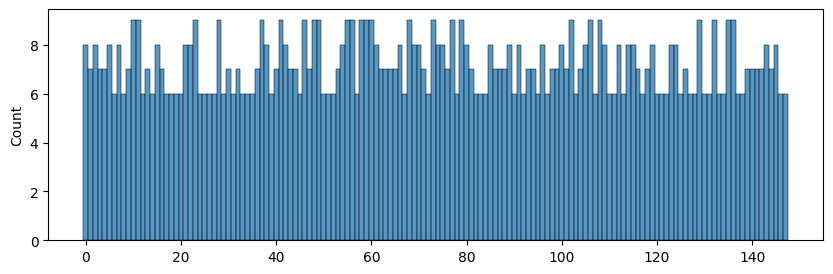

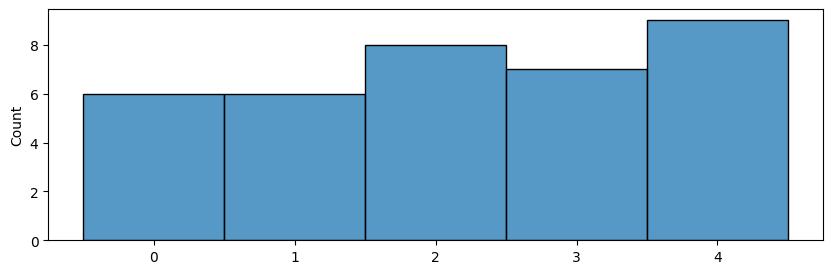

In [7]:
def show_class_distribtion(targets):
    plt.figure(figsize=(10,3))
    sns.histplot(targets, bins=len(set(targets)), discrete=True)
    plt.show()
    

show_class_distribtion(train_ds.targets)
show_class_distribtion(test_ds.targets)

##### [0 баллов] Задание 1.2. Датасет пар.

Как было сказано ранее, мы будем обучать модели предсказывать, разные ли люди изображены на фотографиях. Для этого нам надо научиться формировать пары фотографий и целевую переменную из двух классов: 0 и 1. \
Класс 0 означает, что это фотографии одного человека. \
Класс 1 означает фотографии разных людей. \
 \
К счастью, весь датасет уже написан.

In [8]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.targets = [ self._get_target(i) for i in tqdm.trange(len(self)) ]

    def _idx1(self, idx):
        return idx % len(self.dataset)
    
    def _idx2(self, idx):
        return idx // len(self.dataset)
    
    def _get_target(self, idx):
        return int(self.dataset.targets[self._idx1(idx)] != self.dataset.targets[self._idx2(idx)])

    def __len__(self):
        return len(self.dataset) ** 2

    def __getitem__(self, idx):
        image1, label1 = self.dataset[self._idx1(idx)]
        image2, label2 = self.dataset[self._idx2(idx)]
        return image1, image2, int(label1 != label2)
    
train_pairs = PairDataset(train_ds)
test_pairs = PairDataset(test_ds)

100%|██████████| 1296/1296 [00:00<00:00, 2645166.90it/s]


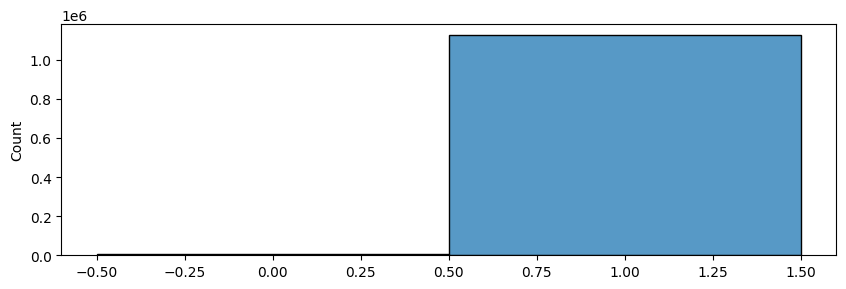

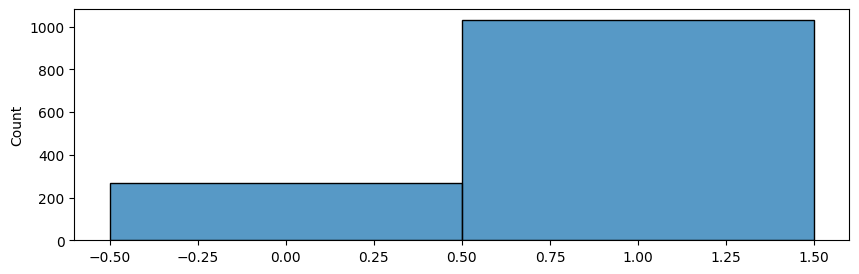

In [9]:
show_class_distribtion(train_pairs.targets)
show_class_distribtion(test_pairs.targets)

Легко видеть, что пар фотографий разных людей гораздо больше, чем пар фотографий одного человека. Это вполне ожидаемо, но, если не предпринять мер, ведет к двум проблемам:
1. Метрика качества предсказаний должна учитывать дисбаланс классов. В частности, accuracy нам не подойдёт. А использовать будем известный из курса машинного обучения AUC-ROC.
2. Нужно "подтюнить" даталоадер тренировочных данных, чтобы в каждый батч попадало примерно одинаковое количество фотографий каждого класса. Иначе победить деградацию модели к "всегда 1" будет очень сложно.

##### [1 балл] Задание 1.3. Стратифицированный даталоадер.

Для начала решим вторую проблему. Нужно сделать такой даталоадер, чтобы в каждом батче количество элементов класса "0" совпадало с количеством элементов класса "1".

Как известно, стандартный класс `DataLoader` в torch имеет много параметров. В частности, параметр `sampler` позволяет гибко управлять выдачей. Изучите [документацию](https://docs.pytorch.org/docs/stable/data.html#data-loading-order-and-sampler) и реализуйте свой семплер, который решит проблему.

В `pytorch_metric_learning` уже есть готовая реализация того, что нам нужно. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.4__.

In [10]:
class BalancedSampler(torch.utils.data.Sampler):
    def __init__(self, labels, num_samples=None, neg_class=0, pos_class=1):
        super().__init__(None)
        self.labels = torch.as_tensor(labels)
        self.neg_class_inds = torch.where(self.labels == neg_class)[0]
        self.pos_class_inds = torch.where(self.labels == pos_class)[0]

        self.num_samples = num_samples or 2 * max(len(self.neg_class_inds), len(self.pos_class_inds))

    def __iter__(self):
        half = self.num_samples // 2

        pos_idx = torch.randint(high=len(self.pos_class_inds), size=(half,), dtype=torch.long)
        neg_idx = torch.randint(high=len(self.neg_class_inds), size=(half,), dtype=torch.long)

        pos_choice = self.pos_class_inds[pos_idx]
        neg_choice = self.neg_class_inds[neg_idx]

        inds = torch.cat([pos_choice, neg_choice])
        inds = inds[torch.randperm(len(inds))]

        return iter(inds.tolist())

    def __len__(self):
        return self.num_samples


In [11]:
train_pairs_sampler = BalancedSampler(train_pairs.targets, num_samples=len(train_pairs))

In [12]:
train_pairs.targets.count(1), train_pairs.targets.count(0)

(1126382, 7843)

In [36]:
targets = torch.tensor(train_pairs.targets)

class_sample_counts = torch.bincount(targets)
weights = 1. / class_sample_counts.float()
sample_weights = weights[targets]

train_pairs_sampler = data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=32000,
    replacement=True
)
weights

tensor([1.2750e-04, 8.8780e-07])

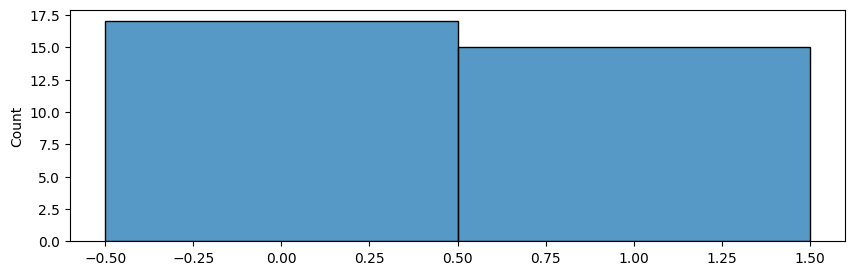

In [40]:
train_pairs_loader = torch.utils.data.DataLoader(train_pairs, batch_size = 32, sampler=train_pairs_sampler, shuffle=False)
test_pairs_loader = torch.utils.data.DataLoader(test_pairs, batch_size = 64, shuffle = False)

# Убедимся, что теперь выдача равномерная.
show_class_distribtion(next(iter(train_pairs_loader))[2])

### [3.5 балла] Часть 2. Классификация.

Начнём с простого: попробуем решить проблему как обычную задачу бинарной классификации. Реализуйте и обучите обычную свёрточную сеть, которая принимает два набора фотографий и предсказывает вероятность, что это фотографии разных людей.

##### [1 балл] Задание 2.1. Модель классификации.

Сначала нужно реализовать модель. В `forward` необходимо принять два батча фотографий. `i`-e число в выводе `forward` должно быть предсказанием для пары из `i`-й фотографии `image1` и `i`-й фотографии `image2`. Подумайте, как это сделать. Возможно, стоит как-нибудь склеить `image1` и `image2`? Или склеить эмбеддинги? А может быть нужен какой-то трешхолд?

Вы вольны использовать любую архитектуру сети. Ассерт в конце ячейки поможет вам убедиться, что модель теоретически делает то, что нужно.

In [16]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc="Train"):
    model.train()
    train_loss, all_labels, all_preds = 0.0, [], []

    for images, labels in tqdm.tqdm(train_loader, desc=tqdm_desc):
        images = images.to(device)
        labels = labels.to(device).long()
    
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)

        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1).detach().cpu()
        all_preds.append(preds)
        all_labels.append(labels.detach().cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    train_acc = accuracy_score(all_labels.numpy().astype(int), all_preds.numpy().astype(int))
    
    train_loss /= len(train_loader.dataset)

    return train_loss, train_acc

@torch.no_grad()
def validation_epoch(model, criterion, valid_loader, tqdm_desc="Valid"):
    model.eval()
    val_loss, all_labels, all_preds = 0.0, [], []

    for images, labels in tqdm.tqdm(valid_loader, desc=tqdm_desc):
        images = images.to(device)
        labels = labels.to(device).long()

        logits = model(images)
        loss = criterion(logits, labels)

        val_loss += loss.item() * images.size(0)

        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1).detach().cpu()
        all_preds.append(preds)
        all_labels.append(labels.detach().cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    val_acc = accuracy_score(all_labels.numpy().astype(int), all_preds.numpy().astype(int))

    val_loss /= len(valid_loader.dataset)

    return val_loss, val_acc

def plot_metrics(train_losses, val_losses, train_acc, val_acc):
    clear_output(True)
    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss", marker="o")
    plt.plot(epochs, val_losses, label="Val Loss", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Dynamics")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train Accuracy", marker="o")
    plt.plot(epochs, val_acc, label="Val Accuracy", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Dynamics")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

def train(model, optimizer, criterion, train_loader, val_loader, num_epochs, scheduler=None):
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    best_val_loss = float("inf")

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = training_epoch(model=model, optimizer=optimizer, criterion=criterion, train_loader=train_loader, tqdm_desc=f"Training {epoch}/{num_epochs}")
        val_loss, val_acc = validation_epoch(model=model, criterion=criterion, valid_loader=val_loader, tqdm_desc=f"Validating {epoch}/{num_epochs}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if scheduler is not None:
            scheduler.step(val_loss)

        plot_metrics(train_losses, val_losses, train_accs, val_accs)

        print(f"[{epoch:02d}/{num_epochs}] Train: loss={train_loss:.4f}, Accuracy={train_acc:.4f} | Val: loss={val_loss:.4f}, Accuracy={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
        
        torch.save(model.state_dict(), f'models/model2_0_epoch_{epoch}.tar')

    return train_losses, val_losses, train_acc, val_acc

In [17]:
class Model(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(p=0.4),
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2)),
            nn.Flatten()
        )

        self.classifier = nn.Sequential(
            nn.Linear(2048, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Linear(2048, 148),
        )
    
    def forward(self, x):
        x = self.encoder(x)
        return self.classifier(x)

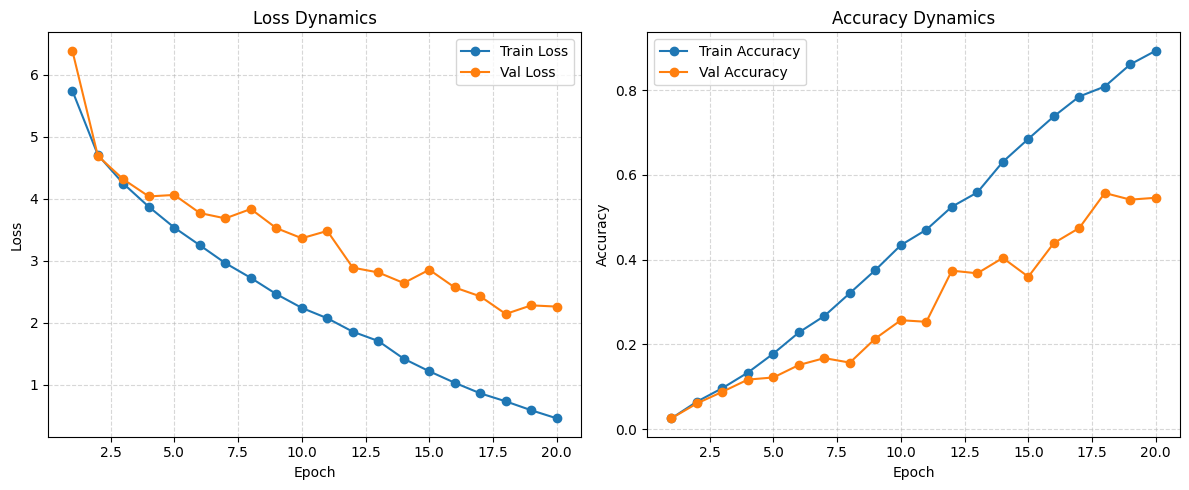

[20/20] Train: loss=0.4607, Accuracy=0.8930 | Val: loss=2.2611, Accuracy=0.5460


Model(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Dropout2d(p=0.4, inplace=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1))
    (12): ReLU()
    (13): AdaptiveAvgPool2d(output_size=(2, 2))
    (14): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=2048, bias=True)
    (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=

In [21]:
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
ds = torchvision.datasets.ImageFolder('data/train_augmented', transform=transform)
test_dataset, train_dataset = data.random_split(ds, (0.3, 0.7))

test_loader = data.DataLoader(dataset=test_dataset, batch_size=64)
train_loader = data.DataLoader(dataset=train_dataset, batch_size=64)

model = Model().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0025)
# scheduler = torch.optim.lr_scheduler.ExponentialLR()
criterion = nn.CrossEntropyLoss()
epochs = 20

train(model, optimizer, criterion, train_loader, test_loader, epochs)
model.eval()

In [22]:
device

device(type='mps')

In [35]:
class ClassificationNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        model = Model()
        model.load_state_dict(torch.load('models/model2_0_epoch_18.tar'))
        self.encoder = model.encoder
        self.encoder.requires_grad_(False)

        self.classifier = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Dropout(p=0.15),
            nn.Linear(64, 1)
        )

    def forward(self, image1, image2):
        e1 = self.encoder(image1)
        e2 = self.encoder(image2)
        
        d = torch.abs(e1 - e2)
        out = self.classifier(d)
        return out.squeeze(1)

# Вы можете использовать этот ассерт в качестве теста, что ваша модель делает то, что нужно.
assert ClassificationNet()(*next(iter(train_pairs_loader))[:2]).shape == (32,)

##### [2 балла] Задание 2.2. Обучение.

Теперь обучите свою модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 2.5 \cdot \dfrac{AucRoc - 0.6}{0.2}, 2.5) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.8`

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1)

In [41]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc="Train"):
    model.train()
    train_loss, all_labels, all_preds = 0.0, [], []

    for image1, image2, labels in tqdm.tqdm(train_loader, desc=tqdm_desc):
        image1 = image1.to(device)
        image2 = image2.to(device)
        labels = labels.to(device).float()
    
        optimizer.zero_grad()
        logits = model(image1, image2)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * image1.size(0)

        probs = torch.sigmoid(logits).detach().cpu()
        all_preds.append(probs)
        all_labels.append(labels.detach().cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    try:
        train_roc_auc = roc_auc_score(all_labels.numpy(), all_preds.numpy())
    except ValueError:
        train_roc_auc = float("nan")

    train_loss /= len(train_loader.sampler)

    return train_loss, train_roc_auc

@torch.no_grad()
def validation_epoch(model, criterion, valid_loader, tqdm_desc="Valid"):
    model.eval()
    val_loss, all_labels, all_preds = 0.0, [], []

    for image1, image2, labels in tqdm.tqdm(valid_loader, desc=tqdm_desc):
        image1 = image1.to(device)
        image2 = image2.to(device)
        labels = labels.to(device).float()

        logits = model(image1, image2)
        loss = criterion(logits, labels)

        val_loss += loss.item() * image1.size(0)

        probs = torch.sigmoid(logits).detach().cpu()
        all_preds.append(probs)
        all_labels.append(labels.detach().cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    try:
        val_roc_auc = roc_auc_score(all_labels.numpy(), all_preds.numpy())
    except ValueError:
        val_roc_auc = float("nan")

    val_loss /= len(valid_loader.dataset)

    return val_loss, val_roc_auc

def plot_metrics(train_losses, val_losses, train_aucs, val_aucs):
    clear_output(True)
    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss", marker="o")
    plt.plot(epochs, val_losses, label="Val Loss", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Dynamics")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_aucs, label="Train ROC-AUC", marker="o")
    plt.plot(epochs, val_aucs, label="Val ROC-AUC", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("ROC-AUC Dynamics")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

def train(model, optimizer, criterion, train_loader, val_loader, num_epochs, scheduler=None):
    train_losses, train_aucs = [], []
    val_losses, val_aucs = [], []

    best_val_loss = float("inf")

    for epoch in range(1, num_epochs + 1):
        train_loss, train_roc_auc = training_epoch(model=model, optimizer=optimizer, criterion=criterion, train_loader=train_loader, tqdm_desc=f"Training {epoch}/{num_epochs}")
        val_loss, val_roc_auc = validation_epoch(model=model, criterion=criterion, valid_loader=val_loader, tqdm_desc=f"Validating {epoch}/{num_epochs}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_aucs.append(train_roc_auc)
        val_aucs.append(val_roc_auc)

        if scheduler is not None:
            scheduler.step(val_loss)

        plot_metrics(train_losses, val_losses, train_aucs, val_aucs)

        print(f"[{epoch:02d}/{num_epochs}] Train: loss={train_loss:.4f}, AUC={train_roc_auc:.4f} | Val: loss={val_loss:.4f}, AUC={val_roc_auc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
        
        torch.save(model.state_dict(), f=f'models/model2_epoch_{epoch}.tar')

    print("\n=== Final Metrics ===")
    print(f"Train ROC-AUC (avg): {np.nanmean(train_aucs):.4f}")
    print(f"Val ROC-AUC (avg):   {np.nanmean(val_aucs):.4f}")

    return train_losses, val_losses, train_aucs, val_aucs

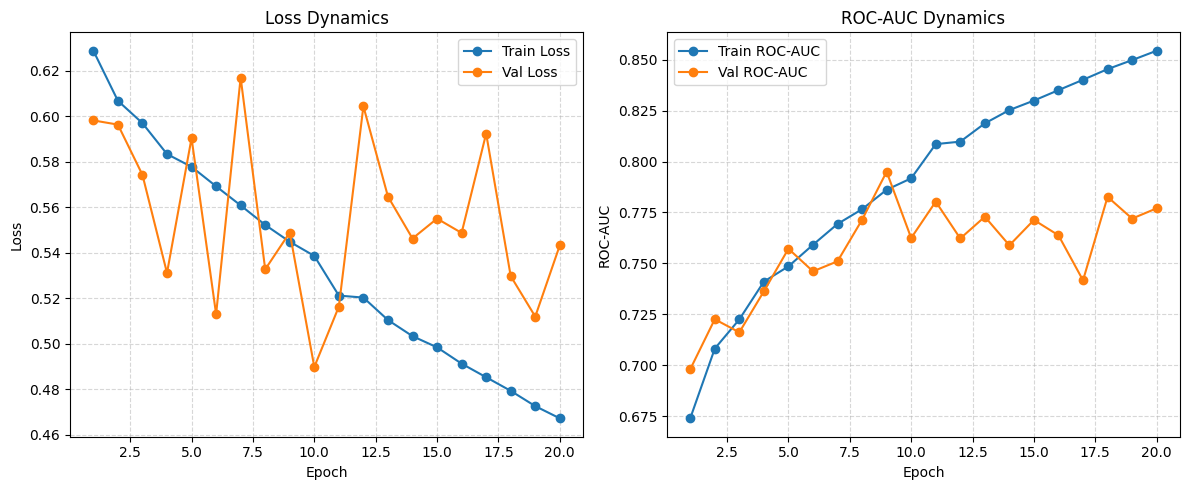

[20/20] Train: loss=0.4672, AUC=0.8544 | Val: loss=0.5433, AUC=0.7770

=== Final Metrics ===
Train ROC-AUC (avg): 0.7897
Val ROC-AUC (avg):   0.7569


([0.6288118937909604,
  0.6067938142716884,
  0.5969591425657272,
  0.5833740963339805,
  0.5777685061991215,
  0.5692064813673496,
  0.5607981022894383,
  0.5522237374782563,
  0.5448259451389312,
  0.5386015008091927,
  0.5211550590395927,
  0.5202781483232976,
  0.5104094963669777,
  0.5033202653825283,
  0.49840600219368936,
  0.4912358832657337,
  0.4852577904164791,
  0.47927937838435175,
  0.4725563853532076,
  0.4671900239139795],
 [0.5981688484733487,
  0.5963236137672707,
  0.5742226559438823,
  0.5311103235056371,
  0.5903830778451613,
  0.5129743137477357,
  0.6169909908447737,
  0.5326902424847638,
  0.5488865978923845,
  0.48976485670348746,
  0.516306264165007,
  0.6043902569346957,
  0.5646992907112027,
  0.5462535627094316,
  0.5549948701152095,
  0.5487052069769965,
  0.592388297304695,
  0.5297328800330927,
  0.5119267584365091,
  0.5432561326909948],
 [np.float64(0.6738962615800371),
  np.float64(0.7081284730937814),
  np.float64(0.722473917952818),
  np.float64(0.7

In [42]:
model = ClassificationNet().to('mps')
device = 'mps'
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer)
criterion = nn.BCEWithLogitsLoss()
epochs = 20

train(model, optimizer, criterion, train_pairs_loader, test_pairs_loader, epochs, scheduler)

In [43]:
def get_score(auc_roc):
    return max(0, min(2.5 * (auc_roc - 0.6) / 0.2, 2.5))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            output = your_model(images1.to(device), images2.to(device))
        preds.extend(output.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = np.array(preds)
    targets = np.array(targets)
    return roc_auc_score(targets, preds)

get_score(get_auc_roc(model))

100%|██████████| 21/21 [00:14<00:00,  1.45it/s]


np.float64(2.212752755675597)

##### [0.5 балла] Задание 2.3. Анализ и отчет.

Опишите свои эксперименты. Проанализируйте результаты. Почему результаты получились не очень хорошими? Может быть, решать задачу через бинарную классификацию - не лучшая идея? Приведите не менее 3 аргументов, почему это так.

### [5 баллов] Часть 3. Распознавание лиц.

Теперь попробуем использовать более хитрые методы, которые лучше подходят для решаемой задачи. В частности, триплетную функцию потерь. Далее наша модель будет не предсказывать вероятность для двух картинок, а формировать эмбеддинги для одной картинки таким образом, чтобы эмбеддинги фотографий одного человека были близки, а разных людей - далеки.

##### [2 балла] Задание 3.1. Триплетная функция потерь.

Напомним теорию. Пусть $A$ - произвольное изображение; $P$ - изображение того же человека (позитивный пример); $N$ - изображение любого другого человека (негативный пример); $f$ - наша нейронная сеть; $\alpha$ - гиперпараметр, отвечающий за желаемый “отступ” – расстояние между латентными представлениями изображений разных людей. Тогда функционал ошибки определяется следующим образом:

$$ L(A, P, N) = max(||f(A) - f(P)|| - ||f(A) - f(N)|| + \alpha, 0) $$

В этом задании вам необходимо реализовать этот функционал. Для удобства в дальнейшем, предлагается сразу реализовать batch-версию. Таким образом, на входе должно быть 2 параметра:
- Набор эмбеддингов размера (batch_size, embedding_size)
- Набор классов (номера людей, чьи это фотографии) размера (batch_size)

Ваша функция должна найти все тройки $(A, P, N)$ и вычислить лосс для них.

В `pytorch_metric_learning` уже есть готовая реализация. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.5__.

In [ ]:
criterion = ### YOUR CODE HERE ###(margin = 0.25)

In [ ]:
# Вы можете использовать этот ассерт в качестве теста
embeddings = torch.tensor([
    [ 1., 2, 3 ],
    [ 1, 3, 4 ],
    [ 4, 5, 6 ]
])
labels = torch.tensor([ 1., 2, 1 ])
assert (criterion(embeddings, labels) - 2.6775) < 1e-4

##### [3 балла] Задание 3.2. Обучение.

Теперь обучите модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 3 \cdot \dfrac{AucRoc - 0.8}{0.15}, 3) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.95`

При необходимости, вы можете улучшить функцию потерь. Например, учитывать не все тройки, а только "сложные", как это умеет делать реализация в `pytorch_metric_learning`. Также подумайте над даталоадером. Возможно, имеет смысл брать в батч одинаковое количество фотографий каждого человека по аналгии с заданием 1.3? Тем не менее имейте в виду, что для получения полного балла за задание, вы должны реализовать все модификации самостоятельно, а не использовать готовые.

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1.5) \
__При использовани pytorch_metric_learning, балл за это задание уменьшается на 0.5 за каждое использование__

In [ ]:
### YOUR CODE HERE ###

In [ ]:
def get_score(auc_roc):
    return max(0, min(3 * (auc_roc - 0.8) / 0.15, 3))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            emb1 = your_model(images1.to(device))
            emb2 = your_model(images2.to(device))
            # Вы можете изменить функцию расстояния между эмбеддингами, если считаете нужным
            dist = ((emb1 - emb2) ** 2).sum(dim = 1)
        preds.extend(dist.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = numpy.array(preds)
    targets = numpy.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

get_score(get_auc_roc(model))

##### [0.1 балла] Бонус: распознай себя

В качестве бонуса, загрузите свою фотографию (можно не одну), пропустите ее через модель и определите, на кого из известных людей, по мнению модели, вы больше всего похоже.

In [ ]:
### YOUR CODE HERE ###